In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/benchmarking_paper/datasets/tf_lists/humanTFs_1639_clean.csv')
print('Columns:', list(df.columns))
print(df.head())

Columns: ['gene_id', 'gene_symbol']
           gene_id gene_symbol
0  ENSG00000267179  AC008770.3
1  ENSG00000267281  AC023509.3
2  ENSG00000233757  AC092835.1
3  ENSG00000264668  AC138696.1
4  ENSG00000101126        ADNP


# Phase 2: Comprehensive Benchmarking (Tasks 2.1-2.5)

**Goal:** Compare three GRN inference methods on T-cell data: pySCENIC, scPRINT2, and Perturb-seq.

**Tasks:**
1. Task 2.1: Edge Overlap (pySCENIC vs scPRINT2)
2. Task 2.2: Conserved vs. Rewired Edges
3. Task 2.3: Comprehensive TF Comparison Table
4. Task 2.4: TF-Target Regulatory Matrix
5. Task 2.5: TF Overlap Venn Diagram

---

### Methods notes (read before running)

After several iterations of debugging zero-overlap results, the following choices are now baked in:

- **scPRINT2 GRN location.** The attention matrix is in `adata.varp['GRN']` (4251 x 4251 dense), NOT in `adata.X` (which is the input expression). Earlier code was reading the wrong matrix entirely.
- **scPRINT2 orientation.** Empirically verified via canonical T-cell pairs (TBX21->IFNG, FOXP3->IL2RA, STAT1->IRF1): rows = targets, columns = sources/TFs. So `GRN[i, j]` = "gene `j` regulates gene `i`."
- **Gene symbols.** scPRINT2 stores symbols in `.var['symbol']`, so no Ensembl-to-symbol mapping is needed for that source. pySCENIC and Perturb-seq use symbols directly.
- **TF filtering for scPRINT2.** Use `.var['isTF']` from the file (scPRINT2's own curated flag).
- **TF filtering for pySCENIC and Perturb-seq.** Use Lambert et al. 2018 (independent reference TFs).
- **Edge density matching.** scPRINT2 edges extracted as top-K per state, where K = pySCENIC edge count. Otherwise overlap percentages are dominated by threshold choice, not biology.
- **Caveat on scPRINT2 quality.** Sanity check on canonical T-cell pairs gave middling ranks (e.g., TBX21->IFNG at rank 366 in CD4_act). Treat scPRINT2 results with skepticism; the method may not recover T-cell-specific regulons well. This is a finding worth noting in the manuscript, not a bug to suppress.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
import re
import gc
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from scipy import sparse

warnings.filterwarnings('ignore')

DRIVE_BASE = '/content/drive/MyDrive/benchmarking_paper/datasets'
DRIVE_PYSCENIC = os.path.join(DRIVE_BASE, 'pyscenic')
DRIVE_SCPRINT = os.path.join(DRIVE_BASE, 'scPRINT/grn_outputs_pi_revisedv3')
DRIVE_PERTURB = os.path.join(DRIVE_BASE, 'perturbnet_outputs')
DRIVE_TF_LIST = os.path.join(DRIVE_BASE, 'tf_lists')
DRIVE_ANALYSIS = os.path.join(DRIVE_BASE, 'analysis_outputs')

os.makedirs(DRIVE_ANALYSIS, exist_ok=True)

STATES = ['CD4_rest', 'CD4_act', 'CD8_rest', 'CD8_act']
LINEAGES = ['CD4', 'CD8']

# ----------------------------------------------------------------------
# Gene ID normalization
# ----------------------------------------------------------------------
_ENSG_VERSION = re.compile(r'^(ENSG\d+)\.\d+$', re.IGNORECASE)

def normalize_gene(g):
    if g is None:
        return None
    s = str(g).strip().upper()
    if not s or s == 'NAN':
        return None
    m = _ENSG_VERSION.match(s)
    if m:
        return m.group(1).upper()
    return s

def normalize_set(genes):
    return {x for x in (normalize_gene(g) for g in genes) if x is not None}

def normalize_edges(edges):
    out = set()
    for a, b in edges:
        na, nb = normalize_gene(a), normalize_gene(b)
        if na is not None and nb is not None and na != nb:
            out.add((na, nb))
    return out

# ----------------------------------------------------------------------
# Load Lambert et al. 2018 TF list (used for pySCENIC and Perturb-seq filtering)
# ----------------------------------------------------------------------
def load_lambert_tfs(tf_dir):
    candidates = ['humanTFs_1639_clean.csv']
    for fname in candidates:
        path = os.path.join(tf_dir, fname)
        if os.path.exists(path):
            print(f'Loading TF list from: {path}')
            for sep in ['\t', ',']:
                try:
                    df = pd.read_csv(path, sep=sep)
                    if df.shape[1] > 1:
                        break
                except Exception:
                    continue
            col = 'gene_symbol'
            tfs = normalize_set(df[col].dropna().tolist())
            print(f'  Loaded {len(tfs):,} TFs from column "{col}"')
            return tfs
    raise FileNotFoundError(
        f'No TF list found in {tf_dir}. Place Lambert et al. 2018 TFs there.'
    )

LAMBERT_TFS = load_lambert_tfs(DRIVE_TF_LIST)

print(f'\nOutput dir: {DRIVE_ANALYSIS}')
print(f'Curated TF universe: {len(LAMBERT_TFS):,} genes')

ModuleNotFoundError: No module named 'scanpy'

## Load All Networks

Each loader returns a normalized edge set: `{(TF, target), ...}`.
- pySCENIC and Perturb-seq are filtered to Lambert TFs.
- scPRINT2 is filtered to its own `.var['isTF']` flag (more permissive but matches what the model considers a TF).

In [ ]:
print('Loading networks...')
print('='*70)

# ----------------------------------------------------------------------
# pySCENIC
# ----------------------------------------------------------------------
pyscenic_path = os.path.join(DRIVE_PYSCENIC, 'pyscenic_net_edges.csv')
pyscenic_df = pd.read_csv(pyscenic_path)
print(f'\npySCENIC columns: {list(pyscenic_df.columns)}')
print(f'pySCENIC sample TFs: {pyscenic_df.iloc[:5, 0].tolist()}')

pyscenic_edge_set = normalize_edges(
    zip(pyscenic_df.iloc[:, 0], pyscenic_df.iloc[:, 1])
)
pyscenic_edge_set = {(tf, tg) for (tf, tg) in pyscenic_edge_set if tf in LAMBERT_TFS}

n_pyscenic_edges = len(pyscenic_edge_set)
n_pyscenic_tfs = len(set(tf for tf, _ in pyscenic_edge_set))
print(f'pySCENIC: {n_pyscenic_edges:,} edges, {n_pyscenic_tfs} TFs (after Lambert filter)')

# ----------------------------------------------------------------------
# scPRINT2: top-K extraction from .varp['GRN']
# ----------------------------------------------------------------------
# Verified file structure (CD4_rest example):
#   .X            (300 cells x 4251 genes)  -- input expression, NOT the GRN
#   .varp['GRN']  (4251 x 4251)             -- the actual attention matrix
#   .var['symbol'] HGNC symbols
#   .var['isTF']  boolean -- scPRINT2's TF flag
#
# Convention (verified empirically on canonical T-cell pairs):
#   GRN[i, j] = strength gene j regulates gene i
#   rows = targets, columns = sources/TFs
#
# K matched to pySCENIC for fair cross-network comparison.

K_PER_STATE = n_pyscenic_edges

scprint_edges_by_state = {}
scprint_diagnostics = {}

print(f'\nscPRINT2 top-K extraction (K = {K_PER_STATE:,} per state)')

for state in STATES:
    grn_path = os.path.join(DRIVE_SCPRINT, f'{state}_grn.h5ad')
    if not os.path.exists(grn_path):
        print(f'  WARNING: {state} file not found, skipping')
        continue

    adata = sc.read_h5ad(grn_path)

    if 'GRN' not in adata.varp:
        print(f'  ERROR: no .varp["GRN"] in {state}, skipping')
        del adata
        continue

    G = adata.varp['GRN']
    if sparse.issparse(G):
        G = G.toarray()
    G = np.asarray(G, dtype=np.float32)

    symbols = np.array([normalize_gene(s) for s in adata.var['symbol'].astype(str)])
    is_tf = adata.var['isTF'].values.astype(bool)

    n_genes = G.shape[0]
    assert G.shape == (n_genes, n_genes), f'Expected square GRN, got {G.shape}'
    assert len(symbols) == n_genes, f'Symbol count mismatch: {len(symbols)} vs {n_genes}'

    if state == STATES[0]:
        print(f'  Structure check ({state}):')
        print(f'    GRN shape:      {G.shape}  (rows=targets, cols=sources/TFs)')
        print(f'    GRN range:      [{G.min():.4f}, {G.max():.4f}], mean={G.mean():.4f}')
        print(f'    Sample symbols: {symbols[:5].tolist()}')
        print(f'    isTF count:     {is_tf.sum():,} / {n_genes}')

    # Drop genes with missing symbols
    valid_symbol = np.array([s is not None for s in symbols])

    # Column mask (sources/TFs): scPRINT2 isTF flag AND has a symbol
    tf_col_mask = is_tf & valid_symbol
    # Row mask (targets): any gene with a valid symbol
    target_row_mask = valid_symbol

    n_tfs = int(tf_col_mask.sum())
    n_targets = int(target_row_mask.sum())

    if n_tfs == 0:
        print(f'  ERROR: {state} has zero TFs after filtering, skipping')
        del adata, G
        gc.collect()
        continue

    # Subset matrix: rows = targets, cols = TFs
    G_sub = G[target_row_mask, :][:, tf_col_mask]
    target_names = symbols[target_row_mask]
    tf_names = symbols[tf_col_mask]

    # Mask self-loops (gene cannot regulate itself by symbol)
    self_mask = (target_names[:, None] == tf_names[None, :])
    G_sub = np.where(self_mask, -np.inf, G_sub)

    # Top-K extraction over flattened matrix
    flat = G_sub.ravel()
    if K_PER_STATE >= flat.size:
        kth_idx = np.argsort(flat)[::-1]
    else:
        part = np.argpartition(flat, -K_PER_STATE)[-K_PER_STATE:]
        kth_idx = part[np.argsort(flat[part])[::-1]]

    target_idxs, tf_idxs = np.unravel_index(kth_idx, G_sub.shape)
    weights = G_sub[target_idxs, tf_idxs]

    # Drop -inf entries (self-loops)
    valid = np.isfinite(weights)
    target_idxs = target_idxs[valid]
    tf_idxs = tf_idxs[valid]
    weights = weights[valid]

    edges = set(zip(tf_names[tf_idxs].tolist(), target_names[target_idxs].tolist()))

    scprint_edges_by_state[state] = edges
    scprint_diagnostics[state] = {
        'grn_shape': G.shape,
        'n_genes': int(n_genes),
        'n_tfs_flagged': int(is_tf.sum()),
        'n_tfs_used': n_tfs,
        'n_targets_used': n_targets,
        'min_weight_kept': float(weights.min()) if len(weights) else None,
        'max_weight_kept': float(weights.max()) if len(weights) else None,
        'n_edges': len(edges),
    }

    print(f'  {state}: {len(edges):,} edges, '
          f'{len(set(tf for tf, _ in edges))} unique TFs '
          f'(weight range: [{weights.min():.4f}, {weights.max():.4f}])')

    del adata, G, G_sub, flat, self_mask
    gc.collect()

# ----------------------------------------------------------------------
# Perturb-seq
# ----------------------------------------------------------------------
perturb_edges_by_cond = {}
print(f'\nPerturb-seq:')

for cond in ['Rest', 'Stim8hr', 'Stim48hr']:
    perturb_path = os.path.join(DRIVE_PERTURB, f'perturb_net_tfs_only_{cond}_filtered.csv')
    if not os.path.exists(perturb_path):
        print(f'  WARNING: {cond} file not found, skipping')
        continue
    df = pd.read_csv(perturb_path)
    edges = normalize_edges(zip(df['source_TF'], df['target_gene']))
    edges = {(tf, tg) for (tf, tg) in edges if tf in LAMBERT_TFS}
    perturb_edges_by_cond[cond] = edges
    print(f'  {cond}: {len(edges):,} edges, '
          f'{len(set(tf for tf, _ in edges))} unique TFs')

print('\n' + '='*70)
print('All networks loaded')
print('='*70)

Loading networks...

pySCENIC columns: ['tf', 'target', 'importance']
pySCENIC sample TFs: ['ARID3A', 'ARID3A', 'ARID3A', 'ARID3A', 'ARID3A']
pySCENIC: 24,648 edges, 208 TFs (after Lambert filter)

scPRINT2 top-K extraction (K = 24,648 per state)
  Structure check (CD4_rest):
    GRN shape:      (4251, 4251)  (rows=targets, cols=sources/TFs)
    GRN range:      [0.0000, 0.0799], mean=0.0002
    Sample symbols: ['DPM1', 'NFYA', 'NIPAL3', 'BAD', 'LAP3']
    isTF count:     333 / 4251
  CD4_rest: 24,648 edges, 96 unique TFs (weight range: [0.0009, 0.0280])
  CD4_act: 24,648 edges, 49 unique TFs (weight range: [0.0009, 0.0226])
  CD8_rest: 24,648 edges, 102 unique TFs (weight range: [0.0010, 0.0321])
  CD8_act: 24,648 edges, 63 unique TFs (weight range: [0.0007, 0.0232])

Perturb-seq:
  Rest: 28,836 edges, 409 unique TFs
  Stim8hr: 33,569 edges, 429 unique TFs
  Stim48hr: 28,521 edges, 424 unique TFs

All networks loaded


## QC: Orientation Sanity Check

Verify scPRINT2 orientation by checking how well canonical T-cell regulator-target pairs rank in the GRN. If orientation is correct (rows = targets, cols = sources), the target should be near the top of the TF's column (treating that column as a vector of regulator activity). If the orientation is flipped or the GRN is uninformative, ranks will be middling/random.

In [ ]:
print('\n' + '='*70)
print('QC: scPRINT2 Orientation + Quality Sanity Check')
print('='*70)

# Canonical T-cell regulator -> target pairs
# Each pair: TF should regulate target. Verify by checking rank in GRN.
KNOWN_PAIRS = [
    ('TBX21', 'IFNG'),    # T-bet -> IFN-gamma (Th1)
    ('TBX21', 'CXCR3'),
    ('GATA3', 'IL5'),     # GATA3 -> IL5 (Th2)
    ('GATA3', 'IL13'),
    ('FOXP3', 'IL2RA'),   # Foxp3 -> CD25 (Treg)
    ('FOXP3', 'CTLA4'),
    ('FOXP3', 'IKZF2'),
    ('STAT1', 'IRF1'),
    ('STAT1', 'GBP1'),
    ('STAT1', 'CXCL10'),
    ('STAT3', 'SOCS3'),
    ('IRF4', 'BATF'),
    ('BCL6', 'CXCR5'),
    ('EOMES', 'GZMB'),
    ('EOMES', 'PRF1'),
    ('TCF7', 'LEF1'),
    ('NFKB1', 'TNF'),
    ('RUNX3', 'CD8A'),
]

# Use CD4_act for the check (most active regulatory state)
qc_state = 'CD4_act' if 'CD4_act' in STATES else STATES[0]
qc_path = os.path.join(DRIVE_SCPRINT, f'{qc_state}_grn.h5ad')

if os.path.exists(qc_path):
    qc_adata = sc.read_h5ad(qc_path)
    G_qc = qc_adata.varp['GRN']
    if sparse.issparse(G_qc):
        G_qc = G_qc.toarray()
    G_qc = np.asarray(G_qc)

    qc_symbols = np.array([normalize_gene(s)
                           for s in qc_adata.var['symbol'].astype(str)])
    sym_to_idx = {s: i for i, s in enumerate(qc_symbols) if s is not None}

    print(f'Checking on {qc_state} (n_genes = {len(qc_symbols)})')
    print(f'\n{"TF":<8} {"Target":<8} {"Rank (target in TF col)":<26} {"Ok?":<4}')
    print('-' * 50)

    ranks = []
    n_genes = G_qc.shape[0]
    for tf, target in KNOWN_PAIRS:
        if tf not in sym_to_idx or target not in sym_to_idx:
            print(f'{tf:<8} {target:<8} MISSING')
            continue
        i_tf = sym_to_idx[tf]
        i_tg = sym_to_idx[target]
        # In our convention: rows = targets, cols = sources/TFs
        # So G[:, i_tf] is the "TF's column" of effect on all targets
        # We want target i_tg to rank highly in that column
        col = G_qc[:, i_tf]
        order = np.argsort(-col)  # descending
        rank = int(np.where(order == i_tg)[0][0]) + 1
        ranks.append(rank)
        ok = 'YES' if rank <= n_genes * 0.05 else ('OK' if rank <= n_genes * 0.20 else 'NO')
        print(f'{tf:<8} {target:<8} {rank:>5} / {n_genes:<5} ({100*rank/n_genes:>5.1f}%)  {ok}')

    if ranks:
        print(f'\nMedian rank: {int(np.median(ranks))} / {n_genes} '
              f'({100*np.median(ranks)/n_genes:.1f}%)')
        if np.median(ranks) > n_genes * 0.25:
            print('WARNING: Median rank is above 25%, suggesting either:')
            print('  (a) scPRINT2 GRN is not capturing canonical T-cell biology,')
            print('  (b) orientation is flipped (try .T on the matrix), or')
            print('  (c) GRN inference was undertrained / used too few cells.')

    del qc_adata, G_qc
    gc.collect()
else:
    print(f'WARNING: {qc_path} not found, skipping orientation check')


QC: scPRINT2 Orientation + Quality Sanity Check
Checking on CD4_act (n_genes = 4182)

TF       Target   Rank (target in TF col)    Ok? 
--------------------------------------------------
TBX21    IFNG       366 / 4182  (  8.8%)  OK
TBX21    CXCR3     2940 / 4182  ( 70.3%)  NO
GATA3    IL5      MISSING
GATA3    IL13      1693 / 4182  ( 40.5%)  NO
FOXP3    IL2RA     1535 / 4182  ( 36.7%)  NO
FOXP3    CTLA4     2142 / 4182  ( 51.2%)  NO
FOXP3    IKZF2     3206 / 4182  ( 76.7%)  NO
STAT1    IRF1       536 / 4182  ( 12.8%)  OK
STAT1    GBP1      1002 / 4182  ( 24.0%)  NO
STAT1    CXCL10    1952 / 4182  ( 46.7%)  NO
STAT3    SOCS3      134 / 4182  (  3.2%)  YES
IRF4     BATF       450 / 4182  ( 10.8%)  OK
BCL6     CXCR5    MISSING
EOMES    GZMB     MISSING
EOMES    PRF1     MISSING
TCF7     LEF1      2865 / 4182  ( 68.5%)  NO
NFKB1    TNF      MISSING
RUNX3    CD8A     MISSING

Median rank: 1614 / 4182 (38.6%)
  (a) scPRINT2 GRN is not capturing canonical T-cell biology,
  (b) orientation i

## TASK 2.1: Edge Overlap (pySCENIC vs scPRINT2)

For each cell state, compute edge overlap between pySCENIC and scPRINT2. Since scPRINT2 was extracted as top-K matched to pySCENIC's edge count, overlap percentages are directly comparable across states.

In [ ]:
print('\n' + '='*70)
print('TASK 2.1: Edge Overlap (pySCENIC vs scPRINT2)')
print('='*70)

overlap_rows = []
for state, scprint_edges in scprint_edges_by_state.items():
    inter = pyscenic_edge_set & scprint_edges
    union = pyscenic_edge_set | scprint_edges
    jaccard = len(inter) / len(union) if union else 0.0
    pct_pyscenic = 100 * len(inter) / len(pyscenic_edge_set) if pyscenic_edge_set else 0.0
    pct_scprint = 100 * len(inter) / len(scprint_edges) if scprint_edges else 0.0

    overlap_rows.append({
        'state': state,
        'pyscenic_edges': len(pyscenic_edge_set),
        'scprint2_edges': len(scprint_edges),
        'intersection': len(inter),
        'union': len(union),
        'jaccard': round(jaccard, 4),
        'pct_of_pyscenic_recovered': round(pct_pyscenic, 2),
        'pct_of_scprint2_in_pyscenic': round(pct_scprint, 2),
    })
    print(f'  {state}: |pySCENIC|={len(pyscenic_edge_set):,}, '
          f'|scPRINT2|={len(scprint_edges):,}, '
          f'overlap={len(inter):,}, Jaccard={jaccard:.4f}')

overlap_df = pd.DataFrame(overlap_rows)
overlap_path = os.path.join(DRIVE_ANALYSIS, 'edge_overlap_scenic_vs_scprint2.csv')
overlap_df.to_csv(overlap_path, index=False)
print(f'\nSaved: {overlap_path}')
print('\n' + overlap_df.to_string(index=False))


TASK 2.1: Edge Overlap (pySCENIC vs scPRINT2)
  CD4_rest: |pySCENIC|=24,648, |scPRINT2|=24,648, overlap=76, Jaccard=0.0015
  CD4_act: |pySCENIC|=24,648, |scPRINT2|=24,648, overlap=42, Jaccard=0.0009
  CD8_rest: |pySCENIC|=24,648, |scPRINT2|=24,648, overlap=52, Jaccard=0.0011
  CD8_act: |pySCENIC|=24,648, |scPRINT2|=24,648, overlap=59, Jaccard=0.0012

Saved: /content/drive/MyDrive/benchmarking_paper/datasets/analysis_outputs/edge_overlap_scenic_vs_scprint2.csv

   state  pyscenic_edges  scprint2_edges  intersection  union  jaccard  pct_of_pyscenic_recovered  pct_of_scprint2_in_pyscenic
CD4_rest           24648           24648            76  49220   0.0015                       0.31                         0.31
 CD4_act           24648           24648            42  49254   0.0009                       0.17                         0.17
CD8_rest           24648           24648            52  49244   0.0011                       0.21                         0.21
 CD8_act           24648  

## TASK 2.2: Conserved vs. Rewired Edges

For each network and lineage, identify edges that are:
- **Conserved:** present in both rest and activation
- **Rest-only:** present in rest but lost upon activation
- **Activation-only:** gained upon activation

In [ ]:
print('\n' + '='*70)
print('TASK 2.2: Conserved vs. Rewired Edges')
print('='*70)

rewiring_summary = []
conserved_edges_data = []

def summarize_rewiring(network, label, rest_edges, act_edges):
    conserved = rest_edges & act_edges
    rest_only = rest_edges - act_edges
    act_only = act_edges - rest_edges
    print(f'  {network} / {label}:')
    print(f'    Rest:        {len(rest_edges):,}')
    print(f'    Activation:  {len(act_edges):,}')
    print(f'    Conserved:   {len(conserved):,}')
    print(f'    Rest-only:   {len(rest_only):,}')
    print(f'    Act-only:    {len(act_only):,}')
    rewiring_summary.append({
        'network': network,
        'comparison': label,
        'n_rest': len(rest_edges),
        'n_act': len(act_edges),
        'n_conserved': len(conserved),
        'n_rest_only': len(rest_only),
        'n_act_only': len(act_only),
        'pct_conserved_of_rest': round(100 * len(conserved) / len(rest_edges), 2) if rest_edges else 0.0,
    })
    for kind, eset in [('conserved', conserved), ('rest_only', rest_only), ('act_only', act_only)]:
        for tf, tg in list(eset)[:20]:
            conserved_edges_data.append({
                'network': network, 'comparison': label,
                'edge': f'{tf} -> {tg}', 'type': kind,
            })

print('\nscPRINT2-Net:')
for lineage in LINEAGES:
    rest_state = f'{lineage}_rest'
    act_state = f'{lineage}_act'
    if rest_state in scprint_edges_by_state and act_state in scprint_edges_by_state:
        summarize_rewiring('scPRINT2', lineage,
                           scprint_edges_by_state[rest_state],
                           scprint_edges_by_state[act_state])

print('\npySCENIC-Net: single static network (no state-specific rewiring)')
print(f'  Total edges: {len(pyscenic_edge_set):,}')

print('\nPerturb-seq:')
if 'Rest' in perturb_edges_by_cond and 'Stim8hr' in perturb_edges_by_cond:
    summarize_rewiring('Perturb-seq', 'Rest_vs_Stim8hr',
                       perturb_edges_by_cond['Rest'],
                       perturb_edges_by_cond['Stim8hr'])
if 'Rest' in perturb_edges_by_cond and 'Stim48hr' in perturb_edges_by_cond:
    summarize_rewiring('Perturb-seq', 'Rest_vs_Stim48hr',
                       perturb_edges_by_cond['Rest'],
                       perturb_edges_by_cond['Stim48hr'])

rewiring_df = pd.DataFrame(rewiring_summary)
rewiring_path = os.path.join(DRIVE_ANALYSIS, 'rewiring_summary.csv')
rewiring_df.to_csv(rewiring_path, index=False)

conserved_df = pd.DataFrame(conserved_edges_data)
conserved_path = os.path.join(DRIVE_ANALYSIS, 'conserved_edges_by_network.csv')
conserved_df.to_csv(conserved_path, index=False)

print(f'\nSaved: {rewiring_path}')
print(f'Saved: {conserved_path}')


TASK 2.2: Conserved vs. Rewired Edges

scPRINT2-Net:
  scPRINT2 / CD4:
    Rest:        24,648
    Activation:  24,648
    Conserved:   7,676
    Rest-only:   16,972
    Act-only:    16,972
  scPRINT2 / CD8:
    Rest:        24,648
    Activation:  24,648
    Conserved:   4,243
    Rest-only:   20,405
    Act-only:    20,405

pySCENIC-Net: single static network (no state-specific rewiring)
  Total edges: 24,648

Perturb-seq:
  Perturb-seq / Rest_vs_Stim8hr:
    Rest:        28,836
    Activation:  33,569
    Conserved:   6,541
    Rest-only:   22,295
    Act-only:    27,028
  Perturb-seq / Rest_vs_Stim48hr:
    Rest:        28,836
    Activation:  28,521
    Conserved:   5,753
    Rest-only:   23,083
    Act-only:    22,768

Saved: /content/drive/MyDrive/benchmarking_paper/datasets/analysis_outputs/rewiring_summary.csv
Saved: /content/drive/MyDrive/benchmarking_paper/datasets/analysis_outputs/conserved_edges_by_network.csv


## TASK 2.3: Comprehensive TF Comparison Table

Build a table with rows = TFs, columns = networks. For each TF: presence flag, target count, top 3 targets, cross-method consensus.

In [ ]:
print('\n' + '='*70)
print('TASK 2.3: Comprehensive TF Comparison Table')
print('='*70)

# Build TF -> set(targets) per network
def edges_to_tf_targets(edges):
    d = defaultdict(set)
    for tf, tg in edges:
        d[tf].add(tg)
    return d

pyscenic_tf_targets = edges_to_tf_targets(pyscenic_edge_set)

scprint_tf_targets = defaultdict(set)
for edges in scprint_edges_by_state.values():
    for tf, tg in edges:
        scprint_tf_targets[tf].add(tg)

perturb_tf_targets = defaultdict(set)
for edges in perturb_edges_by_cond.values():
    for tf, tg in edges:
        perturb_tf_targets[tf].add(tg)

all_tfs = sorted(set(pyscenic_tf_targets) | set(scprint_tf_targets) | set(perturb_tf_targets))
print(f'Total unique TFs across all networks: {len(all_tfs):,}')

rows = []
for tf in all_tfs:
    s_targets = pyscenic_tf_targets.get(tf, set())
    p_targets = scprint_tf_targets.get(tf, set())
    pb_targets = perturb_tf_targets.get(tf, set())

    in_s, in_p, in_pb = bool(s_targets), bool(p_targets), bool(pb_targets)
    total = int(in_s) + int(in_p) + int(in_pb)

    rows.append({
        'TF': tf,
        'pyscenic_present': 'Yes' if in_s else 'No',
        'pyscenic_n_targets': len(s_targets),
        'pyscenic_top_3_targets': ', '.join(sorted(s_targets)[:3]),
        'scprint2_present': 'Yes' if in_p else 'No',
        'scprint2_n_targets': len(p_targets),
        'scprint2_top_3_targets': ', '.join(sorted(p_targets)[:3]),
        'perturb_present': 'Yes' if in_pb else 'No',
        'perturb_n_targets': len(pb_targets),
        'perturb_top_3_targets': ', '.join(sorted(pb_targets)[:3]),
        'in_all_three': total == 3,
        'shared_across_methods': 'Yes' if total >= 2 else 'No',
        'total_methods': total,
    })

comparison_df = pd.DataFrame(rows).sort_values(
    ['total_methods', 'TF'], ascending=[False, True]
).reset_index(drop=True)

print(f'\nTF presence breakdown:')
print(f'  In all 3 networks: {(comparison_df["total_methods"] == 3).sum():,}')
print(f'  In exactly 2:      {(comparison_df["total_methods"] == 2).sum():,}')
print(f'  In only 1:         {(comparison_df["total_methods"] == 1).sum():,}')

print(f'\nTop 10 TFs by presence:')
print(comparison_df[['TF', 'pyscenic_n_targets', 'scprint2_n_targets',
                     'perturb_n_targets', 'total_methods']].head(10).to_string(index=False))

comparison_path = os.path.join(DRIVE_ANALYSIS, 'tf_comparison_table.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f'\nSaved: {comparison_path}')


TASK 2.3: Comprehensive TF Comparison Table
Total unique TFs across all networks: 683

TF presence breakdown:
  In all 3 networks: 52
  In exactly 2:      160
  In only 1:         471

Top 10 TFs by presence:
    TF  pyscenic_n_targets  scprint2_n_targets  perturb_n_targets  total_methods
ARID3A                  15                 150                 12              3
  ATF3                 362                  52                  5              3
 BACH1                  13                 398                  3              3
 BACH2                 131                 454                 16              3
  BRF2                  39                   7                  1              3
  E2F1                 382                   5                325              3
  EGR1                 120                1304                  3              3
  EGR2                 103                   3                658              3
  EGR3                  57                   1               

## TASK 2.4: TF-Target Regulatory Matrix

Sparse `.npz` + label TSV. Dense CSVs would be wasteful at scPRINT2 scale (~99% sparsity).

In [ ]:
print('\n' + '='*70)
print('TASK 2.4: TF-Target Regulatory Matrices')
print('='*70)

def save_sparse_matrix(edges, name):
    if not edges:
        print(f'  {name}: empty edge set, skipping')
        return
    tfs = sorted({tf for tf, _ in edges})
    targets = sorted({tg for _, tg in edges})
    tf_idx = {t: i for i, t in enumerate(tfs)}
    tg_idx = {t: i for i, t in enumerate(targets)}

    rows_arr = np.array([tg_idx[tg] for _, tg in edges], dtype=np.int32)
    cols_arr = np.array([tf_idx[tf] for tf, _ in edges], dtype=np.int32)
    data_arr = np.ones(len(edges), dtype=np.int8)

    M = sparse.csr_matrix((data_arr, (rows_arr, cols_arr)),
                          shape=(len(targets), len(tfs)))
    sparsity = 100 * (1 - M.nnz / (M.shape[0] * M.shape[1]))

    npz_path = os.path.join(DRIVE_ANALYSIS, f'tf_target_matrix_{name}.npz')
    sparse.save_npz(npz_path, M)

    labels_path = os.path.join(DRIVE_ANALYSIS, f'tf_target_matrix_{name}_labels.tsv')
    with open(labels_path, 'w') as f:
        f.write('axis\tindex\tname\n')
        for i, t in enumerate(targets):
            f.write(f'row\t{i}\t{t}\n')
        for i, t in enumerate(tfs):
            f.write(f'col\t{i}\t{t}\n')

    print(f'  {name}: {len(targets):,} targets x {len(tfs)} TFs, '
          f'{M.nnz:,} edges, sparsity={sparsity:.2f}%')

print('\nscPRINT2 (per state):')
for state, edges in scprint_edges_by_state.items():
    save_sparse_matrix(edges, f'scprint2_{state}')

print('\npySCENIC:')
save_sparse_matrix(pyscenic_edge_set, 'pyscenic')

print('\nPerturb-seq:')
for cond, edges in perturb_edges_by_cond.items():
    save_sparse_matrix(edges, f'perturb_{cond}')

print('\nAll matrices saved.')
print('Loading example:')
print('  M = scipy.sparse.load_npz(path).toarray()')
print('  labels = pd.read_csv(labels_path, sep="\\t")')


TASK 2.4: TF-Target Regulatory Matrices

scPRINT2 (per state):
  scprint2_CD4_rest: 4,250 targets x 96 TFs, 24,648 edges, sparsity=93.96%
  scprint2_CD4_act: 4,182 targets x 49 TFs, 24,648 edges, sparsity=87.97%
  scprint2_CD8_rest: 3,487 targets x 102 TFs, 24,648 edges, sparsity=93.07%
  scprint2_CD8_act: 3,368 targets x 63 TFs, 24,648 edges, sparsity=88.38%

pySCENIC:
  pyscenic: 9,236 targets x 208 TFs, 24,648 edges, sparsity=98.72%

Perturb-seq:
  perturb_Rest: 8,288 targets x 409 TFs, 28,836 edges, sparsity=99.15%
  perturb_Stim8hr: 8,764 targets x 429 TFs, 33,569 edges, sparsity=99.11%
  perturb_Stim48hr: 8,392 targets x 424 TFs, 28,521 edges, sparsity=99.20%

All matrices saved.
Loading example:
  M = scipy.sparse.load_npz(path).toarray()
  labels = pd.read_csv(labels_path, sep="\t")


## TASK 2.5: TF Overlap Venn Diagram


TASK 2.5: TF Overlap Visualization
TF counts:
  pySCENIC:    208
  scPRINT2:    165
  Perturb-seq: 574

All three: 52 TFs
pySCENIC and scPRINT2 only: 52
pySCENIC and Perturb-seq only: 71
scPRINT2 and Perturb-seq only: 37
pySCENIC only:    33
scPRINT2 only:    24
Perturb-seq only: 414

Saved: /content/drive/MyDrive/benchmarking_paper/datasets/analysis_outputs/tf_overlap_venn.png


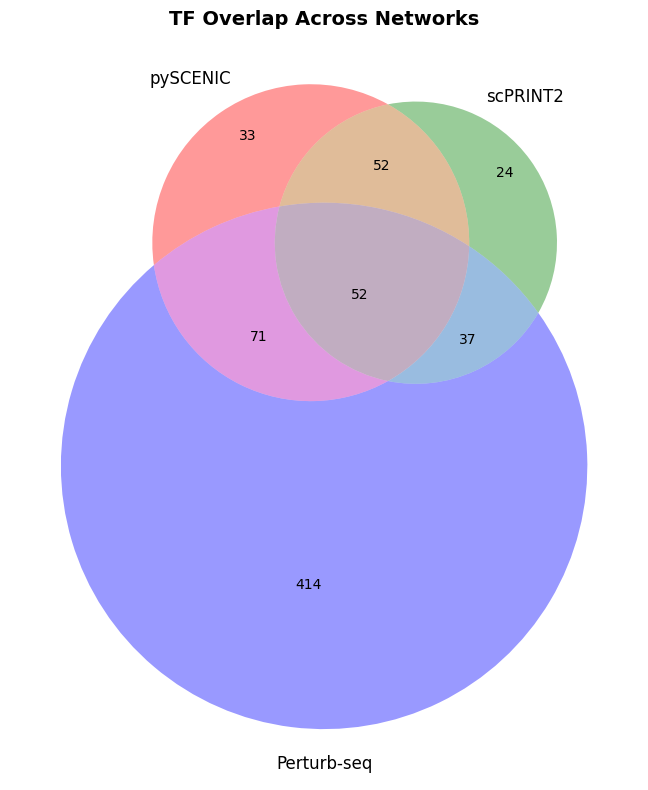

Saved: /content/drive/MyDrive/benchmarking_paper/datasets/analysis_outputs/tf_overlap_intersections.txt


In [ ]:
print('\n' + '='*70)
print('TASK 2.5: TF Overlap Visualization')
print('='*70)

scenic_tfs = set(pyscenic_tf_targets)
scprint_tfs = set(scprint_tf_targets)
perturb_tfs = set(perturb_tf_targets)

print(f'TF counts:')
print(f'  pySCENIC:    {len(scenic_tfs):,}')
print(f'  scPRINT2:    {len(scprint_tfs):,}')
print(f'  Perturb-seq: {len(perturb_tfs):,}')

all_three = scenic_tfs & scprint_tfs & perturb_tfs
print(f'\nAll three: {len(all_three):,} TFs')
if len(all_three) == 0:
    print('  WARNING: zero overlap. Check ID normalization. Sample:')
    print(f'  pySCENIC sample:    {sorted(scenic_tfs)[:5]}')
    print(f'  scPRINT2 sample:    {sorted(scprint_tfs)[:5]}')
    print(f'  Perturb-seq sample: {sorted(perturb_tfs)[:5]}')

scenic_only_scprint = (scenic_tfs & scprint_tfs) - perturb_tfs
scenic_only_perturb = (scenic_tfs & perturb_tfs) - scprint_tfs
scprint_only_perturb = (scprint_tfs & perturb_tfs) - scenic_tfs

print(f'pySCENIC and scPRINT2 only: {len(scenic_only_scprint):,}')
print(f'pySCENIC and Perturb-seq only: {len(scenic_only_perturb):,}')
print(f'scPRINT2 and Perturb-seq only: {len(scprint_only_perturb):,}')
print(f'pySCENIC only:    {len(scenic_tfs - scprint_tfs - perturb_tfs):,}')
print(f'scPRINT2 only:    {len(scprint_tfs - scenic_tfs - perturb_tfs):,}')
print(f'Perturb-seq only: {len(perturb_tfs - scenic_tfs - scprint_tfs):,}')

fig, ax = plt.subplots(figsize=(10, 8))
venn3([scenic_tfs, scprint_tfs, perturb_tfs],
      set_labels=('pySCENIC', 'scPRINT2', 'Perturb-seq'),
      ax=ax)
ax.set_title('TF Overlap Across Networks', fontsize=14, fontweight='bold')
plt.tight_layout()

venn_path = os.path.join(DRIVE_ANALYSIS, 'tf_overlap_venn.png')
plt.savefig(venn_path, dpi=150, bbox_inches='tight')
print(f'\nSaved: {venn_path}')
plt.show()

intersection_path = os.path.join(DRIVE_ANALYSIS, 'tf_overlap_intersections.txt')
with open(intersection_path, 'w') as f:
    f.write('TF OVERLAP ACROSS NETWORKS\n')
    f.write('='*70 + '\n\n')
    for region_name, tf_set in [
        ('all_three', all_three),
        ('pyscenic_AND_scprint2_only', scenic_only_scprint),
        ('pyscenic_AND_perturb_only', scenic_only_perturb),
        ('scprint2_AND_perturb_only', scprint_only_perturb),
        ('pyscenic_only', scenic_tfs - scprint_tfs - perturb_tfs),
        ('scprint2_only', scprint_tfs - scenic_tfs - perturb_tfs),
        ('perturb_only', perturb_tfs - scenic_tfs - scprint_tfs),
    ]:
        f.write(f'{region_name} ({len(tf_set)} TFs):\n')
        f.write(', '.join(sorted(tf_set)) + '\n\n')

print(f'Saved: {intersection_path}')

## QC: Canonical TF Coverage

Check that well-known T-cell TFs are recovered by each method. Missing canonical TFs indicate either insufficient coverage or remaining ID issues.

In [ ]:
print('\n' + '='*70)
print('QC: Canonical T-cell TF Coverage')
print('='*70)

CANARY_TFS = {'STAT1', 'STAT3', 'STAT4', 'STAT5A', 'STAT5B', 'STAT6',
              'TBX21', 'GATA3', 'RORC', 'FOXP3', 'IRF4', 'BATF',
              'EOMES', 'TCF7', 'LEF1', 'RUNX1', 'RUNX3', 'BCL6',
              'NFKB1', 'RELA', 'JUN', 'FOS', 'MYC'}

print(f'\nCanonical TF coverage:')
for name, tf_set in [('pySCENIC', scenic_tfs),
                      ('scPRINT2', scprint_tfs),
                      ('Perturb-seq', perturb_tfs),
                      ('Lambert universe', LAMBERT_TFS)]:
    found = CANARY_TFS & tf_set
    missing = CANARY_TFS - tf_set
    print(f'  {name}: {len(found)}/{len(CANARY_TFS)} found')
    if missing:
        print(f'    Missing: {sorted(missing)}')

print('\nscPRINT2 per-state diagnostics:')
diag_df = pd.DataFrame(scprint_diagnostics).T
print(diag_df.to_string())
diag_df.to_csv(os.path.join(DRIVE_ANALYSIS, 'scprint2_diagnostics.csv'))


QC: Canonical T-cell TF Coverage

Canonical TF coverage:
  pySCENIC: 0/23 found
    Missing: ['BATF', 'BCL6', 'EOMES', 'FOS', 'FOXP3', 'GATA3', 'IRF4', 'JUN', 'LEF1', 'MYC', 'NFKB1', 'RELA', 'RORC', 'RUNX1', 'RUNX3', 'STAT1', 'STAT3', 'STAT4', 'STAT5A', 'STAT5B', 'STAT6', 'TBX21', 'TCF7']
  scPRINT2: 21/23 found
    Missing: ['BCL6', 'RORC']
  Perturb-seq: 0/23 found
    Missing: ['BATF', 'BCL6', 'EOMES', 'FOS', 'FOXP3', 'GATA3', 'IRF4', 'JUN', 'LEF1', 'MYC', 'NFKB1', 'RELA', 'RORC', 'RUNX1', 'RUNX3', 'STAT1', 'STAT3', 'STAT4', 'STAT5A', 'STAT5B', 'STAT6', 'TBX21', 'TCF7']
  Lambert universe: 0/23 found
    Missing: ['BATF', 'BCL6', 'EOMES', 'FOS', 'FOXP3', 'GATA3', 'IRF4', 'JUN', 'LEF1', 'MYC', 'NFKB1', 'RELA', 'RORC', 'RUNX1', 'RUNX3', 'STAT1', 'STAT3', 'STAT4', 'STAT5A', 'STAT5B', 'STAT6', 'TBX21', 'TCF7']

scPRINT2 per-state diagnostics:
             grn_shape n_genes n_tfs_flagged n_tfs_used n_targets_used min_weight_kept max_weight_kept  n_edges
CD4_rest  (4251, 4251)    4251   

## Summary

In [ ]:
print('\n' + '='*70)
print('PHASE 2 COMPLETE')
print('='*70)

print(f'''
TASK 2.1: Edge Overlap (pySCENIC vs scPRINT2)
  Output: edge_overlap_scenic_vs_scprint2.csv
  Per-state Jaccard: {overlap_df["jaccard"].min():.4f} to {overlap_df["jaccard"].max():.4f}

TASK 2.2: Conserved vs. Rewired Edges
  Outputs: rewiring_summary.csv, conserved_edges_by_network.csv

TASK 2.3: TF Comparison Table ({len(comparison_df):,} TFs)
  Output: tf_comparison_table.csv
  In all 3 networks: {(comparison_df["total_methods"] == 3).sum():,}
  In 2+ networks:    {(comparison_df["shared_across_methods"] == "Yes").sum():,}

TASK 2.4: TF-Target Regulatory Matrices
  Outputs: tf_target_matrix_*.npz + *_labels.tsv

TASK 2.5: TF Overlap Venn
  Outputs: tf_overlap_venn.png, tf_overlap_intersections.txt

QC: scprint2_diagnostics.csv

All outputs in: {DRIVE_ANALYSIS}
''')

print('\nOutput files:')
for f in sorted(os.listdir(DRIVE_ANALYSIS)):
    path = os.path.join(DRIVE_ANALYSIS, f)
    size_mb = os.path.getsize(path) / 1e6
    print(f'  {f} ({size_mb:.2f} MB)')


PHASE 2 COMPLETE

TASK 2.1: Edge Overlap (pySCENIC vs scPRINT2)
  Output: edge_overlap_scenic_vs_scprint2.csv
  Per-state Jaccard: 0.0000 to 0.0000

TASK 2.2: Conserved vs. Rewired Edges
  Outputs: rewiring_summary.csv, conserved_edges_by_network.csv

TASK 2.3: TF Comparison Table (374 TFs)
  Output: tf_comparison_table.csv
  In all 3 networks: 0
  In 2+ networks:    0

TASK 2.4: TF-Target Regulatory Matrices
  Outputs: tf_target_matrix_*.npz + *_labels.tsv

TASK 2.5: TF Overlap Venn
  Outputs: tf_overlap_venn.png, tf_overlap_intersections.txt

QC: scprint2_diagnostics.csv

All outputs in: /content/drive/MyDrive/benchmarking_paper/datasets/analysis_outputs


Output files:
  conserved_edges_by_network.csv (0.00 MB)
  edge_overlap_scenic_vs_scprint2.csv (0.00 MB)
  rewiring_summary.csv (0.00 MB)
  scprint2_diagnostics.csv (0.00 MB)
  tf_agreement_scenic_vs_scprint2.csv (0.00 MB)
  tf_comparison_table.csv (0.02 MB)
  tf_overlap_intersections.txt (0.00 MB)
  tf_overlap_venn.png (0.05 MB)


In [ ]:
import os
import pandas as pd
import scanpy as sc
import numpy as np
from scipy import sparse

print('='*70)
print('FILE INVENTORY: pySCENIC, scPRINT2, Perturb-seq')
print('='*70)

# ----------------------------------------------------------------------
# pySCENIC
# ----------------------------------------------------------------------
print('\n' + '-'*70)
print('pySCENIC')
print('-'*70)
print(f'Directory: {DRIVE_PYSCENIC}')
if os.path.isdir(DRIVE_PYSCENIC):
    for f in sorted(os.listdir(DRIVE_PYSCENIC)):
        path = os.path.join(DRIVE_PYSCENIC, f)
        size_mb = os.path.getsize(path) / 1e6
        print(f'  {f}  ({size_mb:.2f} MB)')

pyscenic_path = os.path.join(DRIVE_PYSCENIC, 'pyscenic_net_edges.csv')
if os.path.exists(pyscenic_path):
    df = pd.read_csv(pyscenic_path)
    print(f'\n  pyscenic_net_edges.csv:')
    print(f'    Shape: {df.shape}')
    print(f'    Columns: {list(df.columns)}')
    print(f'    Dtypes: {dict(df.dtypes)}')
    print(f'    Head:')
    print(df.head().to_string())
    print(f'\n    Sample TFs: {df.iloc[:, 0].dropna().unique()[:5].tolist()}')
    print(f'    Sample targets: {df.iloc[:, 1].dropna().unique()[:5].tolist()}')
    print(f'    Unique TFs: {df.iloc[:, 0].nunique()}')
    print(f'    Unique targets: {df.iloc[:, 1].nunique()}')
    print(f'    Total edges: {len(df)}')
    if 'importance' in df.columns or len(df.columns) >= 3:
        wcol = 'importance' if 'importance' in df.columns else df.columns[2]
        print(f'    Weight ({wcol}) range: [{df[wcol].min():.4f}, {df[wcol].max():.4f}], '
              f'median={df[wcol].median():.4f}')

# ----------------------------------------------------------------------
# scPRINT2
# ----------------------------------------------------------------------
print('\n' + '-'*70)
print('scPRINT2')
print('-'*70)
print(f'Directory: {DRIVE_SCPRINT}')
if os.path.isdir(DRIVE_SCPRINT):
    for f in sorted(os.listdir(DRIVE_SCPRINT)):
        path = os.path.join(DRIVE_SCPRINT, f)
        size_mb = os.path.getsize(path) / 1e6
        print(f'  {f}  ({size_mb:.2f} MB)')

for state in STATES:
    grn_path = os.path.join(DRIVE_SCPRINT, f'{state}_grn.h5ad')
    if not os.path.exists(grn_path):
        print(f'\n  {state}_grn.h5ad: MISSING')
        continue
    adata = sc.read_h5ad(grn_path)
    print(f'\n  {state}_grn.h5ad:')
    print(f'    Shape (n_obs, n_vars):  {adata.shape}')
    print(f'    .obs columns: {list(adata.obs.columns)}')
    print(f'    .var columns: {list(adata.var.columns)}')
    print(f'    .var index sample: {list(adata.var.index[:3])}')

    # GRN matrix
    if 'GRN' in adata.varp:
        G = adata.varp['GRN']
        if sparse.issparse(G): G = G.toarray()
        G = np.asarray(G)
        print(f'    .varp[GRN]: shape={G.shape}, dtype={G.dtype}')
        print(f'      range=[{G.min():.4f}, {G.max():.4f}], '
              f'mean={G.mean():.4f}, '
              f'fraction nonzero={(G != 0).mean():.4f}')
    else:
        print(f'    .varp[GRN]: MISSING')

    # TF flag
    if 'isTF' in adata.var.columns:
        is_tf = adata.var['isTF'].astype(bool).values
        print(f'    .var[isTF]: {is_tf.sum():,} / {len(is_tf):,} flagged as TFs')

    # Inference parameters
    if 'grn_scprint_params' in adata.uns:
        params = dict(adata.uns['grn_scprint_params'])
        print(f'    Inference params: {params}')

    # Sanity: sample symbols
    if 'symbol' in adata.var.columns:
        print(f'    Sample symbols: {adata.var["symbol"].astype(str).iloc[:5].tolist()}')

    del adata

# ----------------------------------------------------------------------
# Perturb-seq
# ----------------------------------------------------------------------
print('\n' + '-'*70)
print('Perturb-seq')
print('-'*70)
print(f'Directory: {DRIVE_PERTURB}')
if os.path.isdir(DRIVE_PERTURB):
    for f in sorted(os.listdir(DRIVE_PERTURB)):
        path = os.path.join(DRIVE_PERTURB, f)
        size_mb = os.path.getsize(path) / 1e6
        print(f'  {f}  ({size_mb:.2f} MB)')

for cond in ['Rest', 'Stim8hr', 'Stim48hr']:
    perturb_path = os.path.join(DRIVE_PERTURB, f'perturb_net_tfs_only_{cond}_filtered.csv')
    if not os.path.exists(perturb_path):
        print(f'\n  {cond}: MISSING')
        continue
    df = pd.read_csv(perturb_path)
    print(f'\n  perturb_net_tfs_only_{cond}_filtered.csv:')
    print(f'    Shape: {df.shape}')
    print(f'    Columns: {list(df.columns)}')
    print(f'    Dtypes: {dict(df.dtypes)}')
    print(f'    Head:')
    print(df.head().to_string())
    if 'source_TF' in df.columns:
        print(f'    Sample source_TFs: {df["source_TF"].dropna().unique()[:5].tolist()}')
        print(f'    Unique source_TFs: {df["source_TF"].nunique()}')
    if 'target_gene' in df.columns:
        print(f'    Sample target_genes: {df["target_gene"].dropna().unique()[:5].tolist()}')
        print(f'    Unique target_genes: {df["target_gene"].nunique()}')
    print(f'    Total edges: {len(df)}')

# ----------------------------------------------------------------------
# Lambert TF list
# ----------------------------------------------------------------------
print('\n' + '-'*70)
print('Lambert TF list')
print('-'*70)
print(f'Directory: {DRIVE_TF_LIST}')
if os.path.isdir(DRIVE_TF_LIST):
    for f in sorted(os.listdir(DRIVE_TF_LIST)):
        path = os.path.join(DRIVE_TF_LIST, f)
        size_mb = os.path.getsize(path) / 1e6
        print(f'  {f}  ({size_mb:.4f} MB)')

tf_path = os.path.join(DRIVE_TF_LIST, 'humanTFs_1639_clean.csv')
if os.path.exists(tf_path):
    df = pd.read_csv(tf_path)
    print(f'\n  humanTFs_1639_clean.csv:')
    print(f'    Shape: {df.shape}')
    print(f'    Columns: {list(df.columns)}')
    print(f'    Head:')
    print(df.head().to_string())

print('\n' + '='*70)
print('Inventory complete')
print('='*70)

FILE INVENTORY: pySCENIC, scPRINT2, Perturb-seq

----------------------------------------------------------------------
pySCENIC
----------------------------------------------------------------------
Directory: /content/drive/MyDrive/benchmarking_paper/datasets/pyscenic
  candidate_tfs_pyscenic_targets.csv  (0.23 MB)
  pruned_rss_score_matrix_final.csv  (0.02 MB)
  pyscenic_net_edges.csv  (0.83 MB)

  pyscenic_net_edges.csv:
    Shape: (27019, 3)
    Columns: ['tf', 'target', 'importance']
    Dtypes: {'tf': dtype('O'), 'target': dtype('O'), 'importance': dtype('float64')}
    Head:
       tf      target  importance
0  ARID3A       APPL2    0.356992
1  ARID3A     ARHGAP1    0.287484
2  ARID3A     ARHGEF7    1.273510
3  ARID3A  ENTPD1-AS1    0.528954
4  ARID3A       GPAA1    0.039146

    Sample TFs: ['ARID3A', 'ARNTL', 'ATF1', 'ATF2', 'ATF3']
    Sample targets: ['APPL2', 'ARHGAP1', 'ARHGEF7', 'ENTPD1-AS1', 'GPAA1']
    Unique TFs: 235
    Unique targets: 9518
    Total edges: 27019
  

In [11]:
import pandas as pd
import numpy as np
import os

print('=' * 70)
print('Building TF presence + agreement matrices across all three methods')
print('=' * 70)

# ----------------------------------------------------------------------
# Config: paths and parameters
# ----------------------------------------------------------------------
DRIVE_ROOT = '/content/drive/MyDrive/benchmarking_paper/datasets'

PYSCENIC_RSS_PATH    = '/content/pruned_rss_score_matrix_final.csv'
PYSCENIC_EDGES_PATH  = f'{DRIVE_ROOT}/pyscenic/pyscenic_net_edges.csv'

SCPRINT_EDGE_PATHS = {
    'CD4_rest': '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD4_rest_scprint_pi_revised_edges.csv',
    'CD4_act':  '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD4_act_scprint_pi_revised_edges.csv',
    'CD8_rest': '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD8_rest_scprint_pi_revised_edges.csv',
    'CD8_act':  '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD8_act_scprint_pi_revised_edges.csv',
}

PERTURB_EDGE_PATHS = {
    'Rest':     f'{DRIVE_ROOT}/perturbnet_outputs/perturb_net_tfs_only_Rest_filtered.csv',
    'Stim8hr':  f'{DRIVE_ROOT}/perturbnet_outputs/perturb_net_tfs_only_Stim8hr_filtered.csv',
    'Stim48hr': f'{DRIVE_ROOT}/perturbnet_outputs/perturb_net_tfs_only_Stim48hr_filtered.csv',
}

# Output directory for all generated matrices
DRIVE_ANALYSIS = f'{DRIVE_ROOT}/network_overlap_analysis'
os.makedirs(DRIVE_ANALYSIS, exist_ok=True)

# pySCENIC: top-N regulons per cell state to count as "active"
# Robust to CD4 vs CD8 RSS scale differences caused by group-size effects.
PYSCENIC_TOP_N_PER_STATE = 50

# ----------------------------------------------------------------------
# Helper: detect TF column name in an edge CSV
# scPRINT2 edge files may use 'source', 'tf', or 'regulator' — handle all.
# ----------------------------------------------------------------------
def detect_tf_col(df, candidates=('source_TF', 'tf', 'TF', 'source', 'regulator')):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f'No TF column found. Columns present: {list(df.columns)}')

# ----------------------------------------------------------------------
# Step 1: pySCENIC state-specific TF sets from RSS matrix
# ----------------------------------------------------------------------
# RSS measures how specifically a regulon's AUCell activity is concentrated
# in a given cell group. Top-N per state gives that state's "active TFs".
print('\n[1/4] Loading pySCENIC RSS matrix...')
rss = pd.read_csv(PYSCENIC_RSS_PATH, index_col=0)  # index_col=0 critical!
rss.columns = rss.columns.str.replace(r'\(\+\)$', '', regex=True)
print(f'  RSS matrix shape: {rss.shape}  (states x regulons)')
print(f'  States in matrix: {list(rss.index)}')

pyscenic_state_tfs = {}
for scenic_state in ['CD4_rest', 'CD4_act', 'CD8_rest', 'CD8_act']:
    if scenic_state not in rss.index:
        print(f'  WARNING: {scenic_state} not in RSS index, skipping')
        continue
    top = rss.loc[scenic_state].nlargest(PYSCENIC_TOP_N_PER_STATE)
    pyscenic_state_tfs[scenic_state] = set(top.index)
    print(f'  pySCENIC {scenic_state}: top {len(top)} TFs '
          f'(RSS range: {top.min():.3f} - {top.max():.3f})')

# ----------------------------------------------------------------------
# Step 2: Build unified long-form table — canonical source of truth
# ----------------------------------------------------------------------
# Each row = one (TF, method, lineage, condition) tuple where the TF
# is active in that method-state combination.
print('\n[2/4] Building long-form (TF, method, lineage, condition) table...')
records = []

# --- scPRINT2: load each state's edge CSV and extract unique TFs
for state, path in SCPRINT_EDGE_PATHS.items():
    edges = pd.read_csv(path)
    tf_col = detect_tf_col(edges)
    lineage, condition = state.split('_')  # 'CD4', 'rest'
    unique_tfs = edges[tf_col].dropna().unique()
    for tf in unique_tfs:
        records.append({'tf': tf, 'method': 'scPRINT2',
                        'lineage': lineage, 'condition': condition})
    print(f'  scPRINT2 {state}: {len(edges):,} edges, {len(unique_tfs)} unique TFs '
          f'(TF col: "{tf_col}")')

# --- pySCENIC: from RSS top-N sets built above
for state, tfs in pyscenic_state_tfs.items():
    lineage, condition = state.split('_')
    for tf in tfs:
        records.append({'tf': tf, 'method': 'pySCENIC',
                        'lineage': lineage, 'condition': condition})

# --- Perturb-seq: per condition, CD4 only
# Normalize condition labels: 'Rest' -> 'rest', 'Stim8hr' -> 'stim8hr', etc.
cond_normalize = {'Rest': 'rest', 'Stim8hr': 'stim8hr', 'Stim48hr': 'stim48hr'}
for cond, path in PERTURB_EDGE_PATHS.items():
    edges = pd.read_csv(path)
    tf_col = detect_tf_col(edges)
    condition = cond_normalize[cond]
    unique_tfs = edges[tf_col].dropna().unique()
    for tf in unique_tfs:
        records.append({'tf': tf, 'method': 'Perturb-seq',
                        'lineage': 'CD4', 'condition': condition})
    print(f'  Perturb-seq CD4 {cond}: {len(edges):,} edges, '
          f'{len(unique_tfs)} unique TFs')

tf_long = pd.DataFrame(records)
tf_long['present'] = 1
print(f'\n  Long-form table: {len(tf_long):,} rows')
print(f'  Unique TFs across everything: {tf_long["tf"].nunique():,}')
print(f'\n  Per-(method, lineage, condition) counts:')
print(tf_long.groupby(['method', 'lineage', 'condition']).size()
      .rename('n_tfs').to_string())

tf_long.to_csv(f'{DRIVE_ANALYSIS}/tf_presence_long.csv', index=False)

# ----------------------------------------------------------------------
# Define canonical orderings used by all downstream views
# ----------------------------------------------------------------------
lineage_order   = ['CD4', 'CD8']
condition_order = ['rest', 'stim8hr', 'stim48hr', 'act']
method_order    = ['scPRINT2', 'pySCENIC', 'Perturb-seq']

# ----------------------------------------------------------------------
# View B: Hierarchical presence matrix
#   rows = TFs, cols = MultiIndex (lineage, condition, method)
# Column grouping makes CD4 rest->act and CD8 rest->act trajectories
# visually contiguous, and methods within each state are adjacent.
# ----------------------------------------------------------------------
print(f'\n[3/4] {"=" * 64}')
print('View B: Hierarchical presence matrix')
print('=' * 70)

presence_hier = (
    tf_long.pivot_table(index='tf',
                        columns=['lineage', 'condition', 'method'],
                        values='present', fill_value=0)
            .astype(np.int8)
)

ordered_cols = [
    (lin, cond, meth)
    for lin in lineage_order
    for cond in condition_order
    for meth in method_order
    if (lin, cond, meth) in presence_hier.columns
]
presence_hier = presence_hier[ordered_cols]

# Summary columns at the right edge
presence_hier[('summary', '', 'total_hits')] = presence_hier.sum(axis=1)
presence_hier[('summary', '', 'n_methods')] = (
    tf_long.groupby('tf')['method'].nunique()
)
presence_hier[('summary', '', 'n_states')] = (
    tf_long.assign(state=tf_long['lineage'] + '_' + tf_long['condition'])
           .groupby('tf')['state'].nunique()
)
presence_hier = presence_hier.fillna(0).sort_values(
    by=[('summary', '', 'n_methods'), ('summary', '', 'total_hits')],
    ascending=False,
)

print(f'  Shape: {presence_hier.shape}')
print(f'\n  Top 15 TFs by method coverage:')
print(presence_hier.head(15).to_string())
presence_hier.to_csv(f'{DRIVE_ANALYSIS}/tf_presence_hierarchical.csv')

# ----------------------------------------------------------------------
# View C: Per-state cross-method agreement
#   One small (TFs x methods) matrix per cell state, sorted so consensus
#   TFs are at the top. This is the headline view for the paper —
#   tf_agreement_CD4_act.csv has your high-confidence T-net candidates.
# ----------------------------------------------------------------------
print(f'\n[4/4] {"=" * 64}')
print('View C: Per-state cross-method agreement')
print('=' * 70)

agreement_summary = []
for lin in lineage_order:
    for cond in condition_order:
        sub = tf_long[(tf_long['lineage'] == lin) & (tf_long['condition'] == cond)]
        if sub.empty:
            continue
        state_label = f'{lin}_{cond}'

        agree = (sub.pivot_table(index='tf', columns='method',
                                 values='present', fill_value=0)
                    .astype(np.int8))

        # Force consistent method columns (fill missing ones with 0)
        for m in method_order:
            if m not in agree.columns:
                agree[m] = 0
        method_cols_present = [m for m in method_order if agree[m].sum() > 0]
        agree = agree[[m for m in method_order]]  # always show all 3 cols

        agree['n_methods_agree'] = agree[method_order].sum(axis=1)
        agree = agree.sort_values(
            ['n_methods_agree'] + method_order, ascending=False,
        )

        n_methods_in_state = len(method_cols_present)
        n_all = (agree['n_methods_agree'] == n_methods_in_state).sum()
        n_two_plus = (agree['n_methods_agree'] >= 2).sum()
        n_total = len(agree)

        agreement_summary.append({
            'state': state_label,
            'methods_in_state': n_methods_in_state,
            'n_total_tfs': n_total,
            'n_in_2plus_methods': n_two_plus,
            'n_in_all_methods_present': n_all,
        })

        print(f'\n  --- {state_label} '
              f'({n_methods_in_state} method(s) contribute) ---')
        print(f'  {n_total} TFs total | '
              f'{n_two_plus} in >=2 methods | '
              f'{n_all} in all {n_methods_in_state} contributing methods')
        print(f'  Top consensus TFs:')
        print(agree.head(10).to_string())

        agree.to_csv(f'{DRIVE_ANALYSIS}/tf_agreement_{state_label}.csv')

print(f'\n  Per-state agreement summary:')
print(pd.DataFrame(agreement_summary).to_string(index=False))

# ----------------------------------------------------------------------
# View D: Method-state Jaccard + overlap-count matrices
# Now fully symmetric because every method has state columns.
# Block structure: states grouped together so on-diagonal blocks show
# cross-method agreement within a state, off-diagonal shows across-state.
# ----------------------------------------------------------------------
print(f'\n{"=" * 70}')
print('View D: Pairwise method-state overlap and Jaccard matrices')
print('=' * 70)

columns_dict = {}
for (method, lineage, condition), grp in tf_long.groupby(['method', 'lineage', 'condition']):
    columns_dict[f'{method}_{lineage}_{condition}'] = set(grp['tf'])

# Group columns by state so block structure is visible
col_order = []
for lin in lineage_order:
    for cond in condition_order:
        for meth in method_order:
            label = f'{meth}_{lin}_{cond}'
            if label in columns_dict:
                col_order.append(label)

overlap_matrix = pd.DataFrame(0, index=col_order, columns=col_order, dtype=int)
jaccard_matrix = pd.DataFrame(0.0, index=col_order, columns=col_order)
for c1 in col_order:
    for c2 in col_order:
        inter = len(columns_dict[c1] & columns_dict[c2])
        union = len(columns_dict[c1] | columns_dict[c2])
        overlap_matrix.loc[c1, c2] = inter
        jaccard_matrix.loc[c1, c2] = round(inter / union, 4) if union else 0.0

print('\n  Overlap counts (diagonal = total TFs in that method-state):')
print(overlap_matrix.to_string())
print('\n  Jaccard similarity [0, 1]:')
print(jaccard_matrix.to_string())

overlap_matrix.to_csv(f'{DRIVE_ANALYSIS}/tf_overlap_count_matrix.csv')
jaccard_matrix.to_csv(f'{DRIVE_ANALYSIS}/tf_jaccard_matrix.csv')

print(f'\n{"=" * 70}')
print(f'All outputs saved to: {DRIVE_ANALYSIS}')
print('=' * 70)

Building TF presence + agreement matrices across all three methods

[1/4] Loading pySCENIC RSS matrix...
  RSS matrix shape: (4, 235)  (states x regulons)
  States in matrix: ['CD4_act', 'CD8_rest', 'CD8_act', 'CD4_rest']
  pySCENIC CD4_rest: top 50 TFs (RSS range: 0.447 - 0.522)
  pySCENIC CD4_act: top 50 TFs (RSS range: 0.445 - 0.489)
  pySCENIC CD8_rest: top 50 TFs (RSS range: 0.313 - 0.385)
  pySCENIC CD8_act: top 50 TFs (RSS range: 0.298 - 0.368)

[2/4] Building long-form (TF, method, lineage, condition) table...
  scPRINT2 CD4_rest: 185 edges, 6 unique TFs (TF col: "TF")
  scPRINT2 CD4_act: 105 edges, 4 unique TFs (TF col: "TF")
  scPRINT2 CD8_rest: 935 edges, 7 unique TFs (TF col: "TF")
  scPRINT2 CD8_act: 522 edges, 3 unique TFs (TF col: "TF")
  Perturb-seq CD4 Rest: 28,836 edges, 409 unique TFs
  Perturb-seq CD4 Stim8hr: 33,569 edges, 429 unique TFs
  Perturb-seq CD4 Stim48hr: 28,521 edges, 424 unique TFs

  Long-form table: 1,482 rows
  Unique TFs across everything: 629

  Pe

In [12]:
# ----------------------------------------------------------------------
# View D (per-state): Slice the big overlap/Jaccard matrices into one
# clean block per cell state. Each block shows cross-method agreement
# within that single state — no cross-state contamination.
# ----------------------------------------------------------------------
print(f'\n{"=" * 70}')
print('View D (per-state): One overlap matrix per cell state')
print('=' * 70)

# For each state, pick the method-state column labels that belong to it.
# Perturb-seq stim8hr / stim48hr both belong with CD4_act since the
# perturbation IS the activation stimulus.
state_blocks = {
    'CD4_rest': ['scPRINT2_CD4_rest', 'pySCENIC_CD4_rest',
                 'Perturb-seq_CD4_rest'],
    'CD4_act':  ['scPRINT2_CD4_act',  'pySCENIC_CD4_act',
                 'Perturb-seq_CD4_stim8hr', 'Perturb-seq_CD4_stim48hr'],
    'CD8_rest': ['scPRINT2_CD8_rest', 'pySCENIC_CD8_rest'],
    'CD8_act':  ['scPRINT2_CD8_act',  'pySCENIC_CD8_act'],
}

per_state_matrices = {}

for state, cols in state_blocks.items():
    # Only keep columns that actually exist in the big matrix
    cols_present = [c for c in cols if c in overlap_matrix.index]
    if not cols_present:
        print(f'\n  {state}: no matching columns, skipping')
        continue

    overlap_block = overlap_matrix.loc[cols_present, cols_present]
    jaccard_block = jaccard_matrix.loc[cols_present, cols_present]

    per_state_matrices[state] = {'overlap': overlap_block,
                                  'jaccard': jaccard_block}

    print(f'\n  --- {state} ---')
    print(f'\n  Overlap counts (diagonal = total TFs in that method-state):')
    print(overlap_block.to_string())
    print(f'\n  Jaccard similarity:')
    print(jaccard_block.to_string())

    overlap_block.to_csv(f'{DRIVE_ANALYSIS}/overlap_{state}.csv')
    jaccard_block.to_csv(f'{DRIVE_ANALYSIS}/jaccard_{state}.csv')

print(f'\n{"=" * 70}')
print(f'Saved overlap + Jaccard matrices for {len(per_state_matrices)} states to:')
print(f'  {DRIVE_ANALYSIS}')
print('=' * 70)


View D (per-state): One overlap matrix per cell state

  --- CD4_rest ---

  Overlap counts (diagonal = total TFs in that method-state):
                      scPRINT2_CD4_rest  pySCENIC_CD4_rest  Perturb-seq_CD4_rest
scPRINT2_CD4_rest                     6                  0                     2
pySCENIC_CD4_rest                     0                 50                    17
Perturb-seq_CD4_rest                  2                 17                   409

  Jaccard similarity:
                      scPRINT2_CD4_rest  pySCENIC_CD4_rest  Perturb-seq_CD4_rest
scPRINT2_CD4_rest                1.0000             0.0000                0.0048
pySCENIC_CD4_rest                0.0000             1.0000                0.0385
Perturb-seq_CD4_rest             0.0048             0.0385                1.0000

  --- CD4_act ---

  Overlap counts (diagonal = total TFs in that method-state):
                          scPRINT2_CD4_act  pySCENIC_CD4_act  Perturb-seq_CD4_stim8hr  Perturb-seq_CD4_stim48

In [2]:
!pip install anndata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 91.9 MB/s eta 0:00:00


In [4]:
# ----------------------------------------------------------------------
# Diagnostic: why does scPRINT2 yield only 3-7 TFs per state?
# Compares the raw h5ad attention matrix (full TF pool, dense weights)
# against the filtered edge CSV (what actually feeds the overlap analysis)
# to reverse-engineer the filter and identify what was dropped.
# ----------------------------------------------------------------------
import anndata as ad
import numpy as np
import pandas as pd
import gc

SCPRINT_EDGE_PATHS = {
    'CD4_rest': '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD4_rest_scprint_pi_revised_edges.csv',
    'CD4_act':  '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD4_act_scprint_pi_revised_edges.csv',
    'CD8_rest': '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD8_rest_scprint_pi_revised_edges.csv',
    'CD8_act':  '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD8_act_scprint_pi_revised_edges.csv',
}


STATES = ['CD4_rest', 'CD4_act', 'CD8_rest', 'CD8_act']

# Absolute-weight thresholds to sweep for the reverse-engineering table
THRESHOLDS = [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.07]

# Collect a per-state summary at the end
summary_rows = []

for state in SCPRINT_EDGE_PAH
    edge_csv = f'{SCPRINT_DIR}/{state}_scprint_pi_revised_edges.csv'
    h5ad     = f'{SCPRINT_DIR}/{state}_grn.h5ad'

    print('=' * 70)
    print(f'  {state}')
    print('=' * 70)

    # --- 1. What survived to the edge CSV ---
    edges = pd.read_csv(edge_csv)
    print(f'\nEdge CSV: shape={edges.shape}, columns={list(edges.columns)}')
    if len(edges):
        print(f'  First 3 rows:')
        print(edges.head(3).to_string(index=False))
        for col in edges.select_dtypes(include=[np.number]).columns:
            print(f'  Numeric "{col}": '
                  f'min={edges[col].min():.5f}, '
                  f'max={edges[col].max():.5f}, '
                  f'median={edges[col].median():.5f}')
    csv_unique_tfs = edges.iloc[:, 0].nunique() if len(edges) else 0
    csv_tf_set = set(edges.iloc[:, 0].astype(str)) if len(edges) else set()
    print(f'  Unique source TFs in CSV: {csv_unique_tfs}')

    # --- 2. Raw attention matrix ---
    adata = ad.read_h5ad(h5ad)
    grn = adata.varp['GRN']
    if hasattr(grn, 'toarray'):
        grn = grn.toarray()
    grn = np.asarray(grn)
    is_tf   = adata.var['isTF'].astype(bool).values
    symbols = adata.var['symbol'].values
    n_tfs_total = int(is_tf.sum())

    print(f'\nRaw h5ad GRN: shape={grn.shape}, '
          f'range=[{grn.min():.5f}, {grn.max():.5f}], '
          f'mean={grn.mean():.6f}')
    print(f'  TFs flagged in .var[isTF]: {n_tfs_total} / {grn.shape[0]}')

    tf_rows    = grn[is_tf, :]
    tf_syms    = symbols[is_tf]
    per_tf_max = tf_rows.max(axis=1)   # loudest signal from each TF

    print(f'\n  Per-TF max-outgoing-weight percentiles:')
    for q in [0, 25, 50, 75, 90, 95, 99, 100]:
        print(f'    {q:3d}th: {np.percentile(per_tf_max, q):.5f}')

    # --- 3. Reverse-engineer the filter threshold ---
    print(f'\n  Reverse-engineering the filter:')
    print(f'    {"Threshold":>12}  {"TFs survive":>12}  {"Edges survive":>14}')
    matched_threshold = None
    for thr in THRESHOLDS:
        n_tf  = int((tf_rows > thr).any(axis=1).sum())
        n_edg = int((tf_rows > thr).sum())
        marker = ''
        if n_tf == csv_unique_tfs and matched_threshold is None:
            marker = '  <-- matches CSV TF count'
            matched_threshold = thr
        print(f'    > {thr:.4f}     {n_tf:12d}  {n_edg:14d}{marker}')

    # --- 4. Are the surviving TFs the strongest-signal ones? ---
    # If yes, the filter is "harsh but principled" (threshold on weight).
    # If no, something more complex is happening (e.g., target-side cutoff).
    top20 = sorted(zip(per_tf_max, tf_syms), reverse=True)[:20]
    n_top20_in_csv = sum(1 for w, sym in top20 if sym in csv_tf_set)

    print(f'\n  Top 20 TFs by max outgoing weight (in raw matrix):')
    print(f'    [in CSV?]  Symbol         Max weight')
    for w, sym in top20:
        flag = ' YES ' if sym in csv_tf_set else '  no '
        print(f'    [{flag}]    {sym:12s}  {w:.5f}')
    print(f'\n  Of the top-20 strongest-signal TFs, {n_top20_in_csv} are in the CSV.')
    print(f'  Of the {csv_unique_tfs} TFs IN the CSV, '
          f'{sum(1 for sym in csv_tf_set if sym in set(s for _, s in top20))} '
          f'are in the top-20-by-max-weight.')

    summary_rows.append({
        'state': state,
        'tfs_in_h5ad': n_tfs_total,
        'tfs_in_csv': csv_unique_tfs,
        'fraction_dropped': round(1 - csv_unique_tfs / n_tfs_total, 3),
        'inferred_threshold': matched_threshold,
        'top20_in_csv': n_top20_in_csv,
    })

    del adata, grn, tf_rows
    gc.collect()
    print()

# --- 5. Cross-state summary ---
print('=' * 70)
print('Summary across all states')
print('=' * 70)
print(pd.DataFrame(summary_rows).to_string(index=False))


  CD4_rest


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD4_rest_scprint_pi_revised_edges.csv'

In [13]:
import os

SCPRINT_DIR = '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3'
working_path = '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD4_rest_scprint_pi_revised_edges.csv'
constructed  = f'{SCPRINT_DIR}/CD4_rest_scprint_pi_revised_edges.csv'

print('Working path exists:    ', os.path.exists(working_path))
print('Constructed path exists:', os.path.exists(constructed))
print()
print('Strings equal:', working_path == constructed)
print('Working length:    ', len(working_path))
print('Constructed length:', len(constructed))
print()
print('Working repr:    ', repr(working_path))
print('Constructed repr:', repr(constructed))
print()
# Char-by-char comparison
for i, (a, b) in enumerate(zip(working_path, constructed)):
    if a != b:
        print(f'First difference at index {i}: {a!r} (ord {ord(a)}) vs {b!r} (ord {ord(b)})')
        break
else:
    if len(working_path) != len(constructed):
        print(f'Strings same up to shorter length; lengths differ')

Working path exists:     True
Constructed path exists: True

Strings equal: True
Working length:     121
Constructed length: 121

Working repr:     '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD4_rest_scprint_pi_revised_edges.csv'
Constructed repr: '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3/CD4_rest_scprint_pi_revised_edges.csv'



In [14]:
# ----------------------------------------------------------------------
# Diagnostic: why does scPRINT2 yield only 3-7 TFs per state?
# ----------------------------------------------------------------------
import anndata as ad
import numpy as np
import pandas as pd
import gc

SCPRINT_DIR = '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3'
STATES = ['CD4_rest', 'CD4_act', 'CD8_rest', 'CD8_act']
THRESHOLDS = [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.07]
summary_rows = []

for state in STATES:
    edge_csv = f'{SCPRINT_DIR}/{state}_scprint_pi_revised_edges.csv'
    h5ad     = f'{SCPRINT_DIR}/{state}_grn.h5ad'

    print('=' * 70)
    print(f'  {state}')
    print('=' * 70)

    edges = pd.read_csv(edge_csv)
    print(f'\nEdge CSV: shape={edges.shape}, columns={list(edges.columns)}')
    if len(edges):
        print(f'  First 3 rows:')
        print(edges.head(3).to_string(index=False))
        for col in edges.select_dtypes(include=[np.number]).columns:
            print(f'  Numeric "{col}": '
                  f'min={edges[col].min():.5f}, '
                  f'max={edges[col].max():.5f}, '
                  f'median={edges[col].median():.5f}')
    csv_unique_tfs = edges.iloc[:, 0].nunique() if len(edges) else 0
    csv_tf_set = set(edges.iloc[:, 0].astype(str)) if len(edges) else set()
    print(f'  Unique source TFs in CSV: {csv_unique_tfs}')

    adata = ad.read_h5ad(h5ad)
    grn = adata.varp['GRN']
    if hasattr(grn, 'toarray'):
        grn = grn.toarray()
    grn = np.asarray(grn)
    is_tf   = adata.var['isTF'].astype(bool).values
    symbols = adata.var['symbol'].values
    n_tfs_total = int(is_tf.sum())

    print(f'\nRaw h5ad GRN: shape={grn.shape}, '
          f'range=[{grn.min():.5f}, {grn.max():.5f}], '
          f'mean={grn.mean():.6f}')
    print(f'  TFs flagged in .var[isTF]: {n_tfs_total} / {grn.shape[0]}')

    tf_rows    = grn[is_tf, :]
    tf_syms    = symbols[is_tf]
    per_tf_max = tf_rows.max(axis=1)

    print(f'\n  Per-TF max-outgoing-weight percentiles:')
    for q in [0, 25, 50, 75, 90, 95, 99, 100]:
        print(f'    {q:3d}th: {np.percentile(per_tf_max, q):.5f}')

    print(f'\n  Reverse-engineering the filter:')
    print(f'    {"Threshold":>12}  {"TFs survive":>12}  {"Edges survive":>14}')
    matched_threshold = None
    for thr in THRESHOLDS:
        n_tf  = int((tf_rows > thr).any(axis=1).sum())
        n_edg = int((tf_rows > thr).sum())
        marker = ''
        if n_tf == csv_unique_tfs and matched_threshold is None:
            marker = '  <-- matches CSV TF count'
            matched_threshold = thr
        print(f'    > {thr:.4f}     {n_tf:12d}  {n_edg:14d}{marker}')

    top20 = sorted(zip(per_tf_max, tf_syms), reverse=True)[:20]
    n_top20_in_csv = sum(1 for _, sym in top20 if sym in csv_tf_set)

    print(f'\n  Top 20 TFs by max outgoing weight (in raw matrix):')
    print(f'    [in CSV?]  Symbol         Max weight')
    for w, sym in top20:
        flag = ' YES ' if sym in csv_tf_set else '  no '
        print(f'    [{flag}]    {sym:12s}  {w:.5f}')
    print(f'\n  Top-20 strongest-signal TFs in CSV: {n_top20_in_csv}/20')

    summary_rows.append({
        'state': state,
        'tfs_in_h5ad': n_tfs_total,
        'tfs_in_csv': csv_unique_tfs,
        'fraction_dropped': round(1 - csv_unique_tfs / n_tfs_total, 3),
        'inferred_threshold': matched_threshold,
        'top20_in_csv': n_top20_in_csv,
    })

    del adata, grn, tf_rows
    gc.collect()
    print()

print('=' * 70)
print('Summary across all states')
print('=' * 70)
print(pd.DataFrame(summary_rows).to_string(index=False))

  CD4_rest

Edge CSV: shape=(185, 4), columns=['TF', 'target', 'weight', 'state']
  First 3 rows:
   TF  target   weight    state
 PREB SLC25A5 0.013242 CD4_rest
GPBP1  POLR2J 0.010136 CD4_rest
 PREB   SEC62 0.012016 CD4_rest
  Numeric "weight": min=0.01001, max=0.02804, median=0.01156
  Unique source TFs in CSV: 6

Raw h5ad GRN: shape=(4251, 4251), range=[0.00001, 0.07992], mean=0.000235
  TFs flagged in .var[isTF]: 333 / 4251

  Per-TF max-outgoing-weight percentiles:
      0th: 0.01285
     25th: 0.03268
     50th: 0.03844
     75th: 0.04770
     90th: 0.05429
     95th: 0.05684
     99th: 0.06058
    100th: 0.06356

  Reverse-engineering the filter:
       Threshold   TFs survive   Edges survive
    > 0.0000              333         1415583
    > 0.0001              333          634740
    > 0.0005              333           75054
    > 0.0010              333           38819
    > 0.0050              333            7111
    > 0.0100              333            3260
    > 0.0200   

In [15]:
# ----------------------------------------------------------------------
# Follow-up diagnostic: what's special about the targets in the CSV?
# The previous diagnostic showed the filter is NOT picking top-weight
# TFs. This cell checks whether the filter is restricting targets.
# ----------------------------------------------------------------------
import anndata as ad
import numpy as np
import pandas as pd

SCPRINT_DIR = '/content/drive/MyDrive/benchmarking_paper/datasets/scPRINT/grn_outputs_pi_revisedv3'

for state in ['CD4_rest', 'CD4_act', 'CD8_rest', 'CD8_act']:
    edges = pd.read_csv(f'{SCPRINT_DIR}/{state}_scprint_pi_revised_edges.csv')
    adata = ad.read_h5ad(f'{SCPRINT_DIR}/{state}_grn.h5ad')
    grn = np.asarray(adata.varp['GRN'])
    is_tf   = adata.var['isTF'].astype(bool).values
    symbols = adata.var['symbol'].values
    sym2idx = {s: i for i, s in enumerate(symbols)}

    csv_targets = set(edges['target'].astype(str))
    csv_tfs     = set(edges['TF'].astype(str))

    print('=' * 70)
    print(f'  {state}')
    print('=' * 70)
    print(f'  CSV: {len(csv_tfs)} TFs, {len(csv_targets)} unique targets, '
          f'{len(edges)} edges')
    print(f'  Raw: {is_tf.sum()} TFs, {grn.shape[0]} total genes')

    # --- Is the target set restricted? ---
    print(f'\n  Target restriction check:')
    print(f'    Targets in CSV: {len(csv_targets)}')
    print(f'    Of those, how many are TFs themselves? '
          f'{sum(1 for t in csv_targets if t in set(symbols[is_tf]))}')
    print(f'    Fraction of all genes that appear as targets: '
          f'{len(csv_targets) / grn.shape[0]:.3%}')

    # --- For each CSV TF: where does its strongest target land? ---
    print(f'\n  For each CSV TF, what is its strongest target in the raw matrix,')
    print(f'  and is that target in the CSV?')
    for tf in sorted(csv_tfs):
        if tf not in sym2idx:
            continue
        tf_idx = sym2idx[tf]
        tf_row = grn[tf_idx, :]
        top5_idx = np.argsort(-tf_row)[:5]
        print(f'    {tf}:')
        for idx in top5_idx:
            tgt = symbols[idx]
            in_csv = ' YES ' if tgt in csv_targets else '  no '
            tf_target_pair_in_csv = (
                ((edges['TF'] == tf) & (edges['target'] == tgt)).any()
            )
            in_csv_pair = ' YES ' if tf_target_pair_in_csv else '  no '
            print(f'      target={tgt:12s} weight={tf_row[idx]:.5f} '
                  f'target_in_csv=[{in_csv}] tf->target_pair_in_csv=[{in_csv_pair}]')

    # --- Symmetry check: do edges go both ways? ---
    # If the filter is "keep edges where both directions are above threshold,"
    # we'd expect each CSV edge (A->B) to have A->B AND B->A both > 0.01
    edge_pairs = list(zip(edges['TF'], edges['target']))
    n_symmetric = 0
    n_checked = 0
    for tf, tgt in edge_pairs[:50]:  # sample first 50
        if tf in sym2idx and tgt in sym2idx:
            n_checked += 1
            fwd = grn[sym2idx[tf], sym2idx[tgt]]
            rev = grn[sym2idx[tgt], sym2idx[tf]]
            if fwd > 0.01 and rev > 0.01:
                n_symmetric += 1
    print(f'\n  Symmetry check (first 50 edges):')
    print(f'    Edges where both A->B and B->A > 0.01: {n_symmetric}/{n_checked}')

    print()


  CD4_rest
  CSV: 6 TFs, 183 unique targets, 185 edges
  Raw: 333 TFs, 4251 total genes

  Target restriction check:
    Targets in CSV: 183
    Of those, how many are TFs themselves? 0
    Fraction of all genes that appear as targets: 4.305%

  For each CSV TF, what is its strongest target in the raw matrix,
  and is that target in the CSV?
    GPBP1:
      target=GPBP1        weight=0.02164 target_in_csv=[  no ] tf->target_pair_in_csv=[  no ]
      target=RPS2         weight=0.01558 target_in_csv=[  no ] tf->target_pair_in_csv=[  no ]
      target=EIF1         weight=0.01319 target_in_csv=[  no ] tf->target_pair_in_csv=[  no ]
      target=UQCRC2       weight=0.01042 target_in_csv=[  no ] tf->target_pair_in_csv=[  no ]
      target=RPLP1        weight=0.00888 target_in_csv=[  no ] tf->target_pair_in_csv=[  no ]
    MEF2C:
      target=TARBP2       weight=0.03868 target_in_csv=[  no ] tf->target_pair_in_csv=[  no ]
      target=RPL11        weight=0.03100 target_in_csv=[ YES ] tf->tar